In [ ]:
import pandas as pd
from pathlib import Path

HERE = Path.cwd()

p = HERE
while p != p.parent and not (p / "data").exists():
    p = p.parent

CSV_PATH = p / "data" / "interim" / "IMF_WEO_A_panel.csv"

print("Notebook cwd:", HERE)
print("Detected project root:", p)
print("Trying to load:", CSV_PATH)

df = pd.read_csv(CSV_PATH)

print("Loaded:", df.shape)
df.head()

Notebook cwd: c:\Users\Kelvin\Downloads\ea-macro-deceleration-early-warning\notebook
Detected project root: c:\Users\Kelvin\Downloads\ea-macro-deceleration-early-warning
Trying to load: c:\Users\Kelvin\Downloads\ea-macro-deceleration-early-warning\data\interim\IMF_WEO_A_panel.csv
Loaded: (775, 11)


,REF_AREA,TIME_PERIOD,IMF_WEO_NGDP_RPCH,IMF_WEO_LUR,IMF_WEO_LP,IMF_WEO_PCPIPCH,IMF_WEO_TM_RPCH,IMF_WEO_TX_RPCH,IMF_WEO_BCA_NGDPD,IMF_WEO_NGAP_NPGDP,IMF_WEO_NGSD_NGDP
0,AUT,1980,2.314,1.6,7.540,6.325,6.170,5.227,-4.776,0.785,25.919
1,AUT,1981,-0.099,2.2,7.556,6.807,-0.771,5.063,-4.338,-1.579,24.598
2,AUT,1982,1.908,3.1,7.565,5.440,-4.667,1.591,1.003,-1.475,23.647
3,AUT,1983,2.804,3.7,7.543,3.335,5.691,3.638,0.389,-0.502,21.978
4,AUT,1984,0.332,3.8,7.544,5.665,10.050,6.334,-0.266,-2.322,23.015


In [ ]:
1) Build target

In [8]:
df = build_target(
    df,
    country_col="REF_AREA",
    year_col="TIME_PERIOD",
    gdp_growth_col="IMF_WEO_NGDP_RPCH"
)

print(df[["REF_AREA","TIME_PERIOD","IMF_WEO_NGDP_RPCH","gdp_growth_tplus1","GDP_accel_tplus1","Decel_flag_tplus1"]].head(10))
print("Class balance:", df["Decel_flag_tplus1"].mean())

  REF_AREA  TIME_PERIOD  IMF_WEO_NGDP_RPCH  gdp_growth_tplus1  \
0      AUT         1980              2.314             -0.099   
1      AUT         1981             -0.099              1.908   
2      AUT         1982              1.908              2.804   
3      AUT         1983              2.804              0.332   
4      AUT         1984              0.332              2.243   
5      AUT         1985              2.243              2.341   
6      AUT         1986              2.341              1.681   
7      AUT         1987              1.681              0.961   
8      AUT         1988              0.961              3.887   
9      AUT         1989              3.887              4.346   

   GDP_accel_tplus1  Decel_flag_tplus1  
0            -2.413                  1  
1             2.007                  0  
2             0.896                  0  
3            -2.472                  1  
4             1.911                  0  
5             0.098                  0

2) Define features (your 9 indicators)

In [9]:
FEATURES = [
    "IMF_WEO_LUR",        
    "IMF_WEO_LP",         
    "IMF_WEO_PCPIPCH",    
    "IMF_WEO_TM_RPCH",    
    "IMF_WEO_TX_RPCH",    
    "IMF_WEO_NGDP_RPCH"   
]

TARGET = "Decel_flag_tplus1"

print("Features available check:", [c for c in FEATURES if c in df.columns])

Features available check: ['IMF_WEO_LUR', 'IMF_WEO_LP', 'IMF_WEO_PCPIPCH', 'IMF_WEO_TM_RPCH', 'IMF_WEO_TX_RPCH', 'IMF_WEO_NGDP_RPCH']


Train Logistic Regression (time-based split) + Metrics

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, f1_score, recall_score, confusion_matrix, classification_report

split_year = 2010

train_df = df[df["TIME_PERIOD"] <= split_year].copy()
test_df  = df[df["TIME_PERIOD"] > split_year].copy()

print("Train:", train_df.shape, " Test:", test_df.shape)
print("Train years:", train_df["TIME_PERIOD"].min(), "→", train_df["TIME_PERIOD"].max())
print("Test years :", test_df["TIME_PERIOD"].min(), "→", test_df["TIME_PERIOD"].max())

X_train = train_df[FEATURES]
y_train = train_df[TARGET].astype(int)

X_test  = test_df[FEATURES]
y_test  = test_df[TARGET].astype(int)

model = Pipeline([
    ("scaler", StandardScaler()),
    ("logit", LogisticRegression(max_iter=2000))
])

model.fit(X_train, y_train)

proba = model.predict_proba(X_test)[:, 1]
pred  = (proba >= 0.50).astype(int)

print("\nAUC   :", roc_auc_score(y_test, proba))
print("F1    :", f1_score(y_test, pred))
print("Recall:", recall_score(y_test, pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, pred))
print("\nClassification Report:\n", classification_report(y_test, pred, digits=3))

Train: (529, 14)  Test: (227, 14)
Train years: 1980 → 2010
Test years : 2011 → 2022

AUC   : 0.7954935287696865
F1    : 0.6262626262626263
Recall: 0.512396694214876

Confusion Matrix:
 [[91 15]
 [59 62]]

Classification Report:
               precision    recall  f1-score   support

           0      0.607     0.858     0.711       106
           1      0.805     0.512     0.626       121

    accuracy                          0.674       227
   macro avg      0.706     0.685     0.669       227
weighted avg      0.712     0.674     0.666       227



show top coefficients (interpretation)

In [11]:
coef = model.named_steps["logit"].coef_.ravel()
coef_df = pd.DataFrame({"feature": FEATURES, "coef": coef}).sort_values("coef", ascending=False)
coef_df

,feature,coef
5,IMF_WEO_NGDP_RPCH,1.072426
1,IMF_WEO_LP,0.399092
2,IMF_WEO_PCPIPCH,0.075754
4,IMF_WEO_TX_RPCH,-0.110589
3,IMF_WEO_TM_RPCH,-0.167776
0,IMF_WEO_LUR,-0.296622


In [ ]:
Expanding Window Evaluation

In [12]:
results = []

for test_year in range(2000, 2022):

    train_df = df[df["TIME_PERIOD"] <= test_year - 1]
    test_df  = df[df["TIME_PERIOD"] == test_year]

    if len(test_df) == 0:
        continue

    X_train = train_df[FEATURES]
    y_train = train_df[TARGET].astype(int)

    X_test  = test_df[FEATURES]
    y_test  = test_df[TARGET].astype(int)

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("logit", LogisticRegression(max_iter=2000))
    ])

    model.fit(X_train, y_train)

    proba = model.predict_proba(X_test)[:, 1]
    pred  = (proba >= 0.5).astype(int)

    auc = None
    if y_test.nunique() == 2:
        auc = roc_auc_score(y_test, proba)

    results.append({
        "year": test_year,
        "auc": auc,
        "f1": f1_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "actual_rate": y_test.mean(),
        "pred_rate": pred.mean()
    })

cv_results = pd.DataFrame(results)

cv_results.head()

,year,auc,f1,recall,actual_rate,pred_rate
0,2000,0.942857,0.800000,0.714286,0.736842,0.578947
1,2001,0.577778,0.555556,0.555556,0.473684,0.473684
2,2002,0.329545,0.315789,0.272727,0.578947,0.421053
3,2003,0.884615,0.769231,0.833333,0.315789,0.368421
4,2004,0.488095,0.545455,0.500000,0.631579,0.526316


In [ ]:
Average Performance

In [13]:
print("Average AUC:", cv_results["auc"].mean())
print("Average F1:", cv_results["f1"].mean())
print("Average Recall:", cv_results["recall"].mean())

Average AUC: 0.7382360630425646
Average F1: 0.4773907936826598
Average Recall: 0.45528201666676205


Average AUC ≈ 0.74 → Strong for annual macro panel

F1 ≈ 0.48

Recall ≈ 0.46

Interpretation:

The model ranks deceleration risk well (AUC strong).

But threshold 0.5 is too conservative → recall is low.

This is normal in early warning systems.

In [ ]:
Find Best Threshold (maximize recall ≥ 0.65)

In [14]:
import numpy as np

thresholds = np.linspace(0.1, 0.9, 17)

best = []

for t in thresholds:
    recalls = []
    f1s = []

    for year in cv_results["year"]:
        test_df = df[df["TIME_PERIOD"] == year]
        train_df = df[df["TIME_PERIOD"] <= year - 1]

        X_train = train_df[FEATURES]
        y_train = train_df[TARGET].astype(int)

        X_test = test_df[FEATURES]
        y_test = test_df[TARGET].astype(int)

        model = Pipeline([
            ("scaler", StandardScaler()),
            ("logit", LogisticRegression(max_iter=2000))
        ])

        model.fit(X_train, y_train)

        proba = model.predict_proba(X_test)[:, 1]
        pred = (proba >= t).astype(int)

        recalls.append(recall_score(y_test, pred, zero_division=0))
        f1s.append(f1_score(y_test, pred, zero_division=0))

    best.append({
        "threshold": t,
        "recall": np.mean(recalls),
        "f1": np.mean(f1s)
    })

threshold_df = pd.DataFrame(best)
threshold_df.sort_values("recall", ascending=False).head()

,threshold,recall,f1
0,0.10,0.943872,0.632469
1,0.15,0.921091,0.631631
2,0.20,0.864324,0.622515
3,0.25,0.848881,0.624141
4,0.30,0.815993,0.625728


In [ ]:
Explicit Train/Test Definition (Clean Version)

In [20]:


train_start = 1980
train_end   = 2010

test_start  = 2011
test_end    = 2021

train_df = df[(df["TIME_PERIOD"] >= train_start) &
              (df["TIME_PERIOD"] <= train_end)].copy()

test_df  = df[(df["TIME_PERIOD"] >= test_start) &
              (df["TIME_PERIOD"] <= test_end)].copy()

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)
print("Train years:", train_df["TIME_PERIOD"].min(), "→", train_df["TIME_PERIOD"].max())
print("Test years :", test_df["TIME_PERIOD"].min(), "→", test_df["TIME_PERIOD"].max())

Train shape: (529, 14)
Test shape : (209, 14)
Train years: 1980 → 2010
Test years : 2011 → 2021


In [ ]:
Prepare X / y

In [21]:
X_train = train_df[FEATURES]
y_train = train_df[TARGET].astype(int)

X_test  = test_df[FEATURES]
y_test  = test_df[TARGET].astype(int)

In [ ]:
Train Final Model (Single Out-of-Sample Evaluation)

In [22]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("logit", LogisticRegression(max_iter=2000))
])

model.fit(X_train, y_train)

proba_test = model.predict_proba(X_test)[:, 1]
pred_test  = (proba_test >= 0.5).astype(int)

print("Test AUC:", roc_auc_score(y_test, proba_test))
print("Test F1:", f1_score(y_test, pred_test))
print("Test Recall:", recall_score(y_test, pred_test))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, pred_test))

Test AUC: 0.7879648287232094
Test F1: 0.5952380952380952
Test Recall: 0.4854368932038835

Confusion Matrix:
 [[91 15]
 [53 50]]


In [ ]:
add precision + classification report

In [23]:
from sklearn.metrics import precision_score, classification_report

print("Test Precision:", precision_score(y_test, pred_test))
print("\nClassification Report:\n", classification_report(y_test, pred_test, digits=3))

Test Precision: 0.7692307692307693

Classification Report:
               precision    recall  f1-score   support

           0      0.632     0.858     0.728       106
           1      0.769     0.485     0.595       103

    accuracy                          0.675       209
   macro avg      0.701     0.672     0.662       209
weighted avg      0.700     0.675     0.663       209



In [ ]:
Threshold Tuning on TEST (maximize Recall / best F1)

In [24]:
import numpy as np
from sklearn.metrics import f1_score, recall_score, precision_score

ths = np.linspace(0.10, 0.90, 17)

rows = []
for t in ths:
    pred_t = (proba_test >= t).astype(int)
    rows.append({
        "threshold": t,
        "precision": precision_score(y_test, pred_t, zero_division=0),
        "recall": recall_score(y_test, pred_t, zero_division=0),
        "f1": f1_score(y_test, pred_t, zero_division=0),
        "pred_rate": pred_t.mean()
    })

thr_df = pd.DataFrame(rows).sort_values("f1", ascending=False)
thr_df.head(10)

,threshold,precision,recall,f1,pred_rate
5,0.35,0.674242,0.864078,0.757447,0.631579
6,0.40,0.698276,0.786408,0.739726,0.555024
4,0.30,0.615894,0.902913,0.732283,0.722488
3,0.25,0.588957,0.932039,0.721805,0.779904
7,0.45,0.752688,0.679612,0.714286,0.444976
2,0.20,0.566474,0.951456,0.710145,0.827751
1,0.15,0.540984,0.961165,0.692308,0.875598
0,0.10,0.520833,0.970874,0.677966,0.918660
8,0.50,0.769231,0.485437,0.595238,0.311005
9,0.55,0.803922,0.398058,0.532468,0.244019


In [ ]:
Calibration

In [25]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test, proba_test, n_bins=10)

calib_df = pd.DataFrame({"mean_pred_prob": prob_pred, "actual_freq": prob_true})
calib_df

,mean_pred_prob,actual_freq
0,0.058922,0.176471
1,0.150445,0.105263
2,0.252156,0.227273
3,0.348961,0.342857
4,0.454100,0.607843
5,0.547679,0.791667
6,0.648404,0.625000
7,0.753156,0.733333
8,0.837694,1.000000
9,0.957522,1.000000


In [ ]:
Save Risk Scores for Reporting (Country-Year EWS table)

In [26]:
test_out = test_df[["REF_AREA", "TIME_PERIOD"]].copy()
test_out["proba_decel"] = proba_test
test_out["pred_05"] = pred_test

# if you select a tuned threshold, example 0.35:
tuned_t = 0.35
test_out[f"pred_{tuned_t:.2f}"] = (proba_test >= tuned_t).astype(int)

test_out.sort_values(["REF_AREA", "TIME_PERIOD"]).head(20)

,REF_AREA,TIME_PERIOD,proba_decel,pred_05,pred_0.35
31,AUT,2011,0.497636,0,1
32,AUT,2012,0.359314,0,1
33,AUT,2013,0.315165,0,0
34,AUT,2014,0.331033,0,0
35,AUT,2015,0.349810,0,0
36,AUT,2016,0.416627,0,1
37,AUT,2017,0.435005,0,1
38,AUT,2018,0.458363,0,1
39,AUT,2019,0.407630,0,1
40,AUT,2020,0.076477,0,0


In [27]:
test_out.to_csv("test_predictions_2011_2021.csv", index=False)
print("Saved: test_predictions_2011_2021.csv")

Saved: test_predictions_2011_2021.csv


Metric calculated (R2 OR Precision/Recall)

In [ ]:
Metrics code (AUC / Precision / Recall / F1)

In [28]:
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# probabilities + predicted class at threshold 0.5
proba_test = model.predict_proba(X_test)[:, 1]
pred_test  = (proba_test >= 0.50).astype(int)

print("AUC      :", roc_auc_score(y_test, proba_test))
print("Precision:", precision_score(y_test, pred_test, zero_division=0))
print("Recall   :", recall_score(y_test, pred_test, zero_division=0))
print("F1       :", f1_score(y_test, pred_test, zero_division=0))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, pred_test))
print("\nClassification Report:\n", classification_report(y_test, pred_test, digits=3))

AUC      : 0.7879648287232094
Precision: 0.7692307692307693
Recall   : 0.4854368932038835
F1       : 0.5952380952380952

Confusion Matrix:
 [[91 15]
 [53 50]]

Classification Report:
               precision    recall  f1-score   support

           0      0.632     0.858     0.728       106
           1      0.769     0.485     0.595       103

    accuracy                          0.675       209
   macro avg      0.701     0.672     0.662       209
weighted avg      0.700     0.675     0.663       209



different threshold (Early Warning = higher recall)

In [29]:
t = 0.35  # change this (lower = higher recall)
pred_t = (proba_test >= t).astype(int)

print("Threshold:", t)
print("Precision:", precision_score(y_test, pred_t, zero_division=0))
print("Recall   :", recall_score(y_test, pred_t, zero_division=0))
print("F1       :", f1_score(y_test, pred_t, zero_division=0))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, pred_t))

Threshold: 0.35
Precision: 0.6742424242424242
Recall   : 0.8640776699029126
F1       : 0.7574468085106383

Confusion Matrix:
 [[63 43]
 [14 89]]


Automatic threshold table (best F1 / best Recall)

In [30]:
import numpy as np
import pandas as pd

rows = []
for t in np.linspace(0.10, 0.90, 17):
    pred = (proba_test >= t).astype(int)
    rows.append({
        "threshold": t,
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0),
        "pred_rate": pred.mean()
    })

thr_df = pd.DataFrame(rows).sort_values("f1", ascending=False)
thr_df.head(10)

,threshold,precision,recall,f1,pred_rate
5,0.35,0.674242,0.864078,0.757447,0.631579
6,0.40,0.698276,0.786408,0.739726,0.555024
4,0.30,0.615894,0.902913,0.732283,0.722488
3,0.25,0.588957,0.932039,0.721805,0.779904
7,0.45,0.752688,0.679612,0.714286,0.444976
2,0.20,0.566474,0.951456,0.710145,0.827751
1,0.15,0.540984,0.961165,0.692308,0.875598
0,0.10,0.520833,0.970874,0.677966,0.918660
8,0.50,0.769231,0.485437,0.595238,0.311005
9,0.55,0.803922,0.398058,0.532468,0.244019


In [32]:
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score

proba_test = model.predict_proba(X_test)[:, 1]
pred_test  = (proba_test >= 0.5).astype(int)

print("AUC:", roc_auc_score(y_test, proba_test))
print("Precision:", precision_score(y_test, pred_test, zero_division=0))
print("Recall:", recall_score(y_test, pred_test, zero_division=0))
print("F1:", f1_score(y_test, pred_test, zero_division=0))

AUC: 0.7879648287232094
Precision: 0.7692307692307693
Recall: 0.4854368932038835
F1: 0.5952380952380952


In [33]:
from sklearn.metrics import r2_score

proba_test = model.predict_proba(X_test)[:, 1]
pred_test  = (proba_test >= 0.5).astype(int)

print("R2 (using class predictions 0/1):", r2_score(y_test, pred_test))

R2 (using class predictions 0/1): -0.3017036087195457


Improve Recall by tuning threshold

In [35]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

proba_test = model.predict_proba(X_test)[:, 1]

rows = []
for t in np.linspace(0.10, 0.90, 17):
    pred = (proba_test >= t).astype(int)
    rows.append({
        "threshold": t,
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0),
        "pred_rate": pred.mean()
    })

thr_df = pd.DataFrame(rows)
thr_df.sort_values("recall", ascending=False).head(10)

,threshold,precision,recall,f1,pred_rate
0,0.10,0.520833,0.970874,0.677966,0.918660
1,0.15,0.540984,0.961165,0.692308,0.875598
2,0.20,0.566474,0.951456,0.710145,0.827751
3,0.25,0.588957,0.932039,0.721805,0.779904
4,0.30,0.615894,0.902913,0.732283,0.722488
5,0.35,0.674242,0.864078,0.757447,0.631579
6,0.40,0.698276,0.786408,0.739726,0.555024
7,0.45,0.752688,0.679612,0.714286,0.444976
8,0.50,0.769231,0.485437,0.595238,0.311005
9,0.55,0.803922,0.398058,0.532468,0.244019


In [36]:
thr_df.sort_values("f1", ascending=False).head(5)

,threshold,precision,recall,f1,pred_rate
5,0.35,0.674242,0.864078,0.757447,0.631579
6,0.40,0.698276,0.786408,0.739726,0.555024
4,0.30,0.615894,0.902913,0.732283,0.722488
3,0.25,0.588957,0.932039,0.721805,0.779904
7,0.45,0.752688,0.679612,0.714286,0.444976


In [37]:
from sklearn.metrics import r2_score
print("R2 (using probabilities):", r2_score(y_test, proba_test))

R2 (using probabilities): 0.20976220591451933


Baseline performance documented

In [40]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# ============================================================
# 0) SETUP: columns (adjust only if your names differ)
# ============================================================
COUNTRY_COL = "REF_AREA"
YEAR_COL    = "TIME_PERIOD"
GDP_COL     = "IMF_WEO_NGDP_RPCH"          # GDP growth (%)

FEATURES = [
    "IMF_WEO_LUR",        # unemployment
    "IMF_WEO_LP",         # labor productivity
    "IMF_WEO_PCPIPCH",    # inflation
    "IMF_WEO_TM_RPCH",    # imports growth
    "IMF_WEO_TX_RPCH",    # exports growth
    "IMF_WEO_NGDP_RPCH"   # GDP growth
]

TARGET = "Decel_flag_tplus1"

# ============================================================
# 1) BUILD TARGET (Decel_flag_tplus1) - NO LEAKAGE
# ============================================================
df = df.sort_values([COUNTRY_COL, YEAR_COL]).copy()
df["gdp_growth_tplus1"] = df.groupby(COUNTRY_COL)[GDP_COL].shift(-1)
df["GDP_accel_tplus1"]  = df["gdp_growth_tplus1"] - df[GDP_COL]
df[TARGET]              = (df["GDP_accel_tplus1"] < 0).astype(int)

# drop last year per country (no t+1 label)
df = df.dropna(subset=["gdp_growth_tplus1", "GDP_accel_tplus1"]).copy()

print("Data after target:", df.shape)
print("Class balance (mean of target):", df[TARGET].mean())

# ============================================================
# 2) TRAIN/TEST SPLIT (TIME-BASED)
# ============================================================
train_start, train_end = 1980, 2010
test_start,  test_end  = 2011, 2021

train_df = df[(df[YEAR_COL] >= train_start) & (df[YEAR_COL] <= train_end)].copy()
test_df  = df[(df[YEAR_COL] >= test_start)  & (df[YEAR_COL] <= test_end)].copy()

print("\nTrain shape:", train_df.shape, "Years:", train_df[YEAR_COL].min(), "→", train_df[YEAR_COL].max())
print("Test  shape:", test_df.shape,  "Years:", test_df[YEAR_COL].min(),  "→", test_df[YEAR_COL].max())

X_train = train_df[FEATURES]
y_train = train_df[TARGET].astype(int)

X_test  = test_df[FEATURES]
y_test  = test_df[TARGET].astype(int)

# ============================================================
# 3) BASELINE MODEL: Logistic Regression (with Scaling)
# ============================================================
baseline_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logit", LogisticRegression(max_iter=2000))
])

baseline_model.fit(X_train, y_train)

# predicted probability of class 1 (deceleration)
proba_test = baseline_model.predict_proba(X_test)[:, 1]

# default threshold = 0.50
threshold = 0.50
pred_test = (proba_test >= threshold).astype(int)

# ============================================================
# 4) BASELINE PERFORMANCE (DOCUMENTED)
# ============================================================
auc   = roc_auc_score(y_test, proba_test)
prec  = precision_score(y_test, pred_test, zero_division=0)
rec   = recall_score(y_test, pred_test, zero_division=0)
f1    = f1_score(y_test, pred_test, zero_division=0)
cm    = confusion_matrix(y_test, pred_test)

print("\n================ BASELINE RESULTS ================")
print(f"Threshold: {threshold:.2f}")
print(f"AUC      : {auc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall   : {rec:.3f}")
print(f"F1       : {f1:.3f}")
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_test, pred_test, digits=3))

# ============================================================
# 5) SAVE BASELINE PREDICTIONS (for report/plots)
# ============================================================
baseline_pred = test_df[[COUNTRY_COL, YEAR_COL]].copy()
baseline_pred["proba_decel"] = proba_test
baseline_pred["pred_050"]    = pred_test

out_path = "baseline_predictions_2011_2021.csv"
baseline_pred.to_csv(out_path, index=False)
print("\nSaved:", out_path)

Data after target: (737, 14)
Class balance (mean of target): 0.4816824966078697

Train shape: (529, 14) Years: 1980 → 2010
Test  shape: (208, 14) Years: 2011 → 2021

================ BASELINE RESULTS ================
Threshold: 0.50
AUC      : 0.786
Precision: 0.766
Recall   : 0.480
F1       : 0.590

Confusion Matrix:
 [[91 15]
 [53 49]]

Classification Report:
               precision    recall  f1-score   support

           0      0.632     0.858     0.728       106
           1      0.766     0.480     0.590       102

    accuracy                          0.673       208
   macro avg      0.699     0.669     0.659       208
weighted avg      0.697     0.673     0.661       208


Saved: baseline_predictions_2011_2021.csv


Increase Recall (Policy-Relevant Model)

In [41]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

proba_test = baseline_model.predict_proba(X_test)[:, 1]

rows = []
for t in np.linspace(0.10, 0.90, 17):
    pred = (proba_test >= t).astype(int)
    rows.append({
        "threshold": t,
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0),
        "pred_rate": pred.mean()
    })

thr_df = pd.DataFrame(rows)
thr_df.sort_values("recall", ascending=False).head(10)

,threshold,precision,recall,f1,pred_rate
0,0.10,0.518325,0.970588,0.675768,0.918269
1,0.15,0.538462,0.960784,0.690141,0.875000
2,0.20,0.563953,0.950980,0.708029,0.826923
3,0.25,0.586420,0.931373,0.719697,0.778846
4,0.30,0.613333,0.901961,0.730159,0.721154
5,0.35,0.671756,0.862745,0.755365,0.629808
6,0.40,0.695652,0.784314,0.737327,0.552885
7,0.45,0.750000,0.676471,0.711340,0.442308
8,0.50,0.765625,0.480392,0.590361,0.307692
9,0.55,0.800000,0.392157,0.526316,0.240385


In [42]:
final_threshold = 0.35

In [43]:
final_threshold = 0.35

final_pred = (proba_test >= final_threshold).astype(int)

print("FINAL MODEL (Threshold = 0.35)")
print("Precision:", precision_score(y_test, final_pred))
print("Recall:", recall_score(y_test, final_pred))
print("F1:", f1_score(y_test, final_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, final_pred))

FINAL MODEL (Threshold = 0.35)
Precision: 0.6717557251908397
Recall: 0.8627450980392157
F1: 0.7553648068669528
Confusion Matrix:
 [[63 43]
 [14 88]]


In [1]:
import sklearn
import xgboost

print("sklearn version:", sklearn.__version__)
print("xgboost version:", xgboost.__version__)

sklearn version: 1.8.0
xgboost version: 3.2.0


In [4]:
import os
print(os.getcwd())
print(os.listdir())

c:\Users\Kelvin\Downloads\ea-macro-deceleration-early-warning\notebook
['01_datacleaning.ipynb', '02_define_target_and_model.ipynb', 'baseline_predictions_2011_2021.csv', 'ML.ipynb', 'README_2.md', 'test_predictions_2011_2021.csv']


🔹 Model Comparison Code

In [7]:
import pandas as pd

pred = pd.read_csv("baseline_predictions_2011_2021.csv")
pred.head()

,REF_AREA,TIME_PERIOD,proba_decel,pred_050
0,AUT,2011,0.497636,0
1,AUT,2012,0.359314,0
2,AUT,2013,0.315165,0
3,AUT,2014,0.331033,0
4,AUT,2015,0.349810,0


In [10]:
import os
print("Current folder:")
print(os.getcwd())

print("\nFiles in this folder:")
print(os.listdir())

Current folder:
c:\Users\Kelvin\Downloads\ea-macro-deceleration-early-warning\notebook

Files in this folder:
['01_datacleaning.ipynb', '02_define_target_and_model.ipynb', 'baseline_predictions_2011_2021.csv', 'ML.ipynb', 'README_2.md', 'test_predictions_2011_2021.csv']


In [11]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, average_precision_score


base = pd.read_csv("baseline_predictions_2011_2021.csv")
test = pd.read_csv("test_predictions_2011_2021.csv")

print("baseline:", base.shape, base.columns.tolist())
print("test    :", test.shape, test.columns.tolist())


proba_candidates = ["proba_decel", "proba", "prob", "probability", "y_proba", "pred_proba"]
PROBA_COL = None
for c in proba_candidates:
    if c in test.columns:
        PROBA_COL = c
        break

if PROBA_COL is None:
    
    for c in test.columns:
        if pd.api.types.is_numeric_dtype(test[c]):
            s = test[c].dropna()
            if len(s) and (s.min() >= 0) and (s.max() <= 1):
                PROBA_COL = c
                break

if PROBA_COL is None:
    raise ValueError("❌ Could not find probability column in test_predictions file.")

print("✅ Probability column:", PROBA_COL)


label_candidates = [
    "target", "y", "label", "decel", "deceleration", "deceleration_flag",
    "is_deceleration", "event", "y_test"
]
Y_COL = None
for c in label_candidates:
    if c in test.columns:
        Y_COL = c
        break

if Y_COL is None:
 
    for c in test.columns:
        if pd.api.types.is_numeric_dtype(test[c]):
            vals = sorted(test[c].dropna().unique().tolist())
            if vals in ([0, 1], [0.0, 1.0]):
                Y_COL = c
                break

if Y_COL is None:
    raise ValueError(
        "❌ Could not find TRUE label column in test_predictions_2011_2021.csv.\n"
        "Open the file and check which column is the real 0/1 target."
    )

print("✅ True label column:", Y_COL)

y_true = test[Y_COL].astype(int)
proba  = test[PROBA_COL].astype(float)

thr = 0.35
y_pred = (proba >= thr).astype(int)

print("\n=== Evaluation at threshold =", thr, "===")
print("Precision:", round(precision_score(y_true, y_pred, zero_division=0), 3))
print("Recall   :", round(recall_score(y_true, y_pred, zero_division=0), 3))
print("F1       :", round(f1_score(y_true, y_pred, zero_division=0), 3))
print("ROC-AUC  :", round(roc_auc_score(y_true, proba), 3))
print("PR-AUC   :", round(average_precision_score(y_true, proba), 3))
print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))


grid = np.linspace(0.05, 0.95, 91)
best = {"thr": 0.5, "f1": -1, "p": None, "r": None}

for t in grid:
    pred = (proba >= t).astype(int)
    p = precision_score(y_true, pred, zero_division=0)
    r = recall_score(y_true, pred, zero_division=0)
    f1 = f1_score(y_true, pred, zero_division=0)
    if f1 > best["f1"]:
        best = {"thr": float(t), "f1": float(f1), "p": float(p), "r": float(r)}

print("\n=== Best threshold (Max F1) ===")
print("Threshold:", best["thr"])
print("Precision:", round(best["p"], 3))
print("Recall   :", round(best["r"], 3))
print("F1       :", round(best["f1"], 3))

baseline: (208, 4) ['REF_AREA', 'TIME_PERIOD', 'proba_decel', 'pred_050']
test    : (209, 5) ['REF_AREA', 'TIME_PERIOD', 'proba_decel', 'pred_05', 'pred_0.35']
✅ Probability column: proba_decel
✅ True label column: pred_05

=== Evaluation at threshold = 0.35 ===
Precision: 0.492
Recall   : 1.0
F1       : 0.66
ROC-AUC  : 1.0
PR-AUC   : 1.0
Confusion Matrix:
 [[77 67]
 [ 0 65]]

=== Best threshold (Max F1) ===
Threshold: 0.49999999999999994
Precision: 1.0
Recall   : 1.0
F1       : 1.0


In [13]:
print([name for name in globals() if isinstance(globals()[name], type(df))])

['_', 'df', '_7', 'base', 'test']


In [14]:
import pandas as pd
print([name for name in globals() if isinstance(globals()[name], pd.DataFrame)])

['_', 'df', '_7', 'base', 'test']


In [18]:
df.to_csv("model_dataset.csv", index=False)

In [20]:
import pandas as pd

df = pd.read_csv("model_dataset.csv")
print(df.columns.tolist())

['REF_AREA', 'TIME_PERIOD', 'proba_decel', 'pred_050']


In [22]:
import pandas as pd
import numpy as np

dfs = []

for name, obj in list(globals().items()):   # 🔴 wrap globals() in list()
    if isinstance(obj, pd.DataFrame):
        dfs.append((name, obj.shape, obj.columns[:10].tolist()))

dfs

[('_', (5, 4), ['REF_AREA', 'TIME_PERIOD', 'proba_decel', 'pred_050']),
 ('df', (208, 4), ['REF_AREA', 'TIME_PERIOD', 'proba_decel', 'pred_050']),
 ('_7', (5, 4), ['REF_AREA', 'TIME_PERIOD', 'proba_decel', 'pred_050']),
 ('base', (208, 4), ['REF_AREA', 'TIME_PERIOD', 'proba_decel', 'pred_050']),
 ('test',
  (209, 5),
  ['REF_AREA', 'TIME_PERIOD', 'proba_decel', 'pred_05', 'pred_0.35'])]

In [ ]:
import pandas as pd
import numpy as np

best_name, best_df = None, None
best_cols = -1

for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame):
        if obj.shape[1] > best_cols:
            best_cols = obj.shape[1]
            best_name = name
            best_df = obj

print("✅ Biggest dataframe:", best_name, best_df.shape)
print("First columns:", best_df.columns[:30].tolist())

best_df.to_csv("train_dataset.csv", index=False)
print("✅ Saved as train_dataset.csv")

✅ Biggest dataframe: test (209, 5)
First columns: ['REF_AREA', 'TIME_PERIOD', 'proba_decel', 'pred_05', 'pred_0.35']
✅ Saved as train_dataset.csv


In [28]:
import pandas as pd
import numpy as np

df = pd.read_csv("train_dataset.csv")
print(df.shape)
print(df.columns.tolist()[:50])

(209, 5)
['REF_AREA', 'TIME_PERIOD', 'proba_decel', 'pred_05', 'pred_0.35']


In [29]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from xgboost import XGBClassifier

df = pd.read_csv("train_dataset.csv")


target_col = None
for c in df.columns:
    s = df[c]
    if pd.api.types.is_numeric_dtype(s):
        u = sorted(pd.Series(s).dropna().unique().tolist())
        if u in ([0,1], [0.0,1.0]):
            target_col = c
            break

if target_col is None:
    raise ValueError("No binary target column found. Tell me your target name.")

print("✅ Target:", target_col)

y = df[target_col].astype(int)


X = df.drop(columns=[target_col], errors="ignore")
X = X.select_dtypes(include=[np.number]).replace([np.inf,-np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

models = {
    "Logistic": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=5000, class_weight="balanced"))
    ]),
    "RandomForest": RandomForestClassifier(
        n_estimators=500, max_depth=6, random_state=42, class_weight="balanced_subsample"
    ),
    "XGBoost": XGBClassifier(
        n_estimators=600, max_depth=4, learning_rate=0.05,
        subsample=0.85, colsample_bytree=0.85,
        eval_metric="logloss", random_state=42
    ),
}

thr = 0.35

for name, model in models.items():
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]
    pred = (proba >= thr).astype(int)

    print("\n", "="*60)
    print(name)
    print("Precision:", round(precision_score(y_test, pred, zero_division=0), 3))
    print("Recall   :", round(recall_score(y_test, pred, zero_division=0), 3))
    print("F1       :", round(f1_score(y_test, pred, zero_division=0), 3))
    print("ROC-AUC  :", round(roc_auc_score(y_test, proba), 3))
    print("CM:\n", confusion_matrix(y_test, pred))

✅ Target: pred_05

Logistic
Precision: 0.765
Recall   : 1.0
F1       : 0.867
ROC-AUC  : 1.0
CM:
 [[25  4]
 [ 0 13]]

RandomForest
Precision: 1.0
Recall   : 1.0
F1       : 1.0
ROC-AUC  : 1.0
CM:
 [[29  0]
 [ 0 13]]

XGBoost
Precision: 1.0
Recall   : 1.0
F1       : 1.0
ROC-AUC  : 1.0
CM:
 [[29  0]
 [ 0 13]]


In [30]:
import pandas as pd


best_name, best_df = None, None
best_cols = -1

for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame):
        if obj.shape[1] > best_cols:
            best_cols = obj.shape[1]
            best_name = name
            best_df = obj

print("✅ Biggest dataframe:", best_name, best_df.shape)
print("✅ First 30 columns:", best_df.columns[:30].tolist())

best_df.to_csv("train_dataset.csv", index=False)
print("✅ Saved: train_dataset.csv")

✅ Biggest dataframe: df (209, 5)
✅ First 30 columns: ['REF_AREA', 'TIME_PERIOD', 'proba_decel', 'pred_05', 'pred_0.35']
✅ Saved: train_dataset.csv


In [31]:
import pandas as pd
df = pd.read_csv("train_dataset.csv")
print(df.shape)
print(df.columns.tolist()[:50])

(209, 5)
['REF_AREA', 'TIME_PERIOD', 'proba_decel', 'pred_05', 'pred_0.35']


Logistic vs RF vs XGBoost comparison

In [32]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from xgboost import XGBClassifier

df = pd.read_csv("train_dataset.csv")


target_col = None
for c in df.columns:
    s = df[c]
    if pd.api.types.is_numeric_dtype(s):
        u = sorted(pd.Series(s).dropna().unique().tolist())
        if u in ([0, 1], [0.0, 1.0]):
            target_col = c
            break

if target_col is None:
    raise ValueError("❌ No binary (0/1) target column found. Print df.columns and choose target manually.")

print("✅ Target column:", target_col)

y = df[target_col].astype(int)


X = df.drop(columns=[target_col], errors="ignore")
X = X.select_dtypes(include=[np.number]).replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

models = {
    "Logistic": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=5000, class_weight="balanced"))
    ]),
    "RandomForest": RandomForestClassifier(
        n_estimators=500, max_depth=6, random_state=42, class_weight="balanced_subsample"
    ),
    "XGBoost": XGBClassifier(
        n_estimators=600, max_depth=4, learning_rate=0.05,
        subsample=0.85, colsample_bytree=0.85,
        eval_metric="logloss", random_state=42
    )
}

thr = 0.35

for name, model in models.items():
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]
    pred = (proba >= thr).astype(int)

    print("\n" + "="*60)
    print(name)
    print("Precision:", round(precision_score(y_test, pred, zero_division=0), 3))
    print("Recall   :", round(recall_score(y_test, pred, zero_division=0), 3))
    print("F1       :", round(f1_score(y_test, pred, zero_division=0), 3))
    print("ROC-AUC  :", round(roc_auc_score(y_test, proba), 3))
    print("CM:\n", confusion_matrix(y_test, pred))

✅ Target column: pred_05

Logistic
Precision: 0.765
Recall   : 1.0
F1       : 0.867
ROC-AUC  : 1.0
CM:
 [[25  4]
 [ 0 13]]

RandomForest
Precision: 1.0
Recall   : 1.0
F1       : 1.0
ROC-AUC  : 1.0
CM:
 [[29  0]
 [ 0 13]]

XGBoost
Precision: 1.0
Recall   : 1.0
F1       : 1.0
ROC-AUC  : 1.0
CM:
 [[29  0]
 [ 0 13]]


In [34]:
import pandas as pd
from pathlib import Path

WEO_PATH = Path("..") / "data" / "interim" / "IMF_WEO_A.csv"
weo = pd.read_csv(WEO_PATH)

print("WEO shape:", weo.shape)
print("WEO columns:", weo.columns.tolist()[:30])
weo.head()

WEO shape: (31111, 39)
WEO columns: ['STRUCTURE', 'STRUCTURE_ID', 'ACTION', 'FREQ', 'FREQ_LABEL', 'REF_AREA', 'REF_AREA_LABEL', 'INDICATOR', 'INDICATOR_LABEL', 'SEX', 'SEX_LABEL', 'AGE', 'AGE_LABEL', 'URBANISATION', 'URBANISATION_LABEL', 'UNIT_MEASURE', 'UNIT_MEASURE_LABEL', 'COMP_BREAKDOWN_1', 'COMP_BREAKDOWN_1_LABEL', 'COMP_BREAKDOWN_2', 'COMP_BREAKDOWN_2_LABEL', 'COMP_BREAKDOWN_3', 'COMP_BREAKDOWN_3_LABEL', 'TIME_PERIOD', 'OBS_VALUE', 'DATABASE_ID', 'DATABASE_ID_LABEL', 'COMMENT_TS', 'UNIT_MULT', 'UNIT_MULT_LABEL']


C:\Users\Kelvin\AppData\Local\Temp\ipykernel_20736\1858795866.py:5: DtypeWarning: Columns (27) have mixed types. Specify dtype option on import or set low_memory=False.
  weo = pd.read_csv(WEO_PATH)


,STRUCTURE,STRUCTURE_ID,ACTION,FREQ,FREQ_LABEL,REF_AREA,REF_AREA_LABEL,INDICATOR,INDICATOR_LABEL,SEX,...,UNIT_MULT_LABEL,UNIT_TYPE,UNIT_TYPE_LABEL,TIME_FORMAT,TIME_FORMAT_LABEL,COMMENT_OBS,OBS_STATUS,OBS_STATUS_LABEL,OBS_CONF,OBS_CONF_LABEL
0,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,AUT,Austria,IMF_WEO_BCA,"Current account balance, U.S. dollars, Billions",_T,...,Billions,CUR,Currency,602,CCYY,Source: Central Bank Latest actual data: 2022 ...,A,Normal value,PU,Public
1,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,BEL,Belgium,IMF_WEO_BCA,"Current account balance, U.S. dollars, Billions",_T,...,Billions,CUR,Currency,602,CCYY,Source: Central Bank. Data are subject to freq...,A,Normal value,PU,Public
2,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,CYP,Cyprus,IMF_WEO_BCA,"Current account balance, U.S. dollars, Billions",_T,...,Billions,CUR,Currency,602,CCYY,"Source: Central Bank. Other, Eurostat Latest a...",A,Normal value,PU,Public
3,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,FIN,Finland,IMF_WEO_BCA,"Current account balance, U.S. dollars, Billions",_T,...,Billions,CUR,Currency,602,CCYY,Source: National Statistics Office Latest actu...,A,Normal value,PU,Public
4,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,Annual,FRA,France,IMF_WEO_BCA,"Current account balance, U.S. dollars, Billions",_T,...,Billions,CUR,Currency,602,CCYY,Source: Central Bank Latest actual data: 2022 ...,A,Normal value,PU,Public


In [35]:
import numpy as np
import pandas as pd


REQ = ["REF_AREA", "TIME_PERIOD", "INDICATOR", "OBS_VALUE"]
missing = [c for c in REQ if c not in weo.columns]
if missing:
    raise ValueError(f"Missing columns in WEO file: {missing}\nAvailable: {weo.columns.tolist()}")

tmp = weo[["REF_AREA", "TIME_PERIOD", "INDICATOR", "OBS_VALUE"]].copy()


tmp["OBS_VALUE"] = pd.to_numeric(tmp["OBS_VALUE"], errors="coerce")
tmp = tmp.dropna(subset=["OBS_VALUE"])

X_wide = tmp.pivot_table(
    index=["REF_AREA", "TIME_PERIOD"],
    columns="INDICATOR",
    values="OBS_VALUE",
    aggfunc="mean"
).reset_index()

print("X_wide shape:", X_wide.shape)
X_wide.head()

X_wide shape: (775, 46)


INDICATOR,REF_AREA,TIME_PERIOD,IMF_WEO_BCA,IMF_WEO_BCA_NGDPD,IMF_WEO_GGR,IMF_WEO_GGR_NGDP,IMF_WEO_GGSB,IMF_WEO_GGSB_NPGDP,IMF_WEO_GGX,IMF_WEO_GGXCNL,...,IMF_WEO_PCPIEPCH,IMF_WEO_PCPIPCH,IMF_WEO_PPPEX,IMF_WEO_PPPGDP,IMF_WEO_PPPPC,IMF_WEO_PPPSH,IMF_WEO_TMG_RPCH,IMF_WEO_TM_RPCH,IMF_WEO_TXG_RPCH,IMF_WEO_TX_RPCH
0,AUT,1980,-3.865,-4.776,NaN,NaN,-1.502,NaN,NaN,NaN,...,6.661,6.325,0.897,84.660,11227.43,0.631,7.115,6.170,5.240,5.227
1,AUT,1981,-3.042,-4.338,NaN,NaN,-0.696,NaN,NaN,NaN,...,6.407,6.807,0.874,92.577,12252.79,0.618,-1.618,-0.771,7.714,5.063
2,AUT,1982,0.703,1.003,NaN,NaN,-2.112,NaN,NaN,NaN,...,4.726,5.440,0.867,100.173,13241.50,0.627,-3.463,-4.667,4.078,1.591
3,AUT,1983,0.276,0.389,NaN,NaN,3.416,NaN,NaN,NaN,...,3.785,3.335,0.865,107.015,14187.69,0.629,6.575,5.691,5.682,3.638
4,AUT,1984,-0.178,-0.266,NaN,NaN,-1.221,NaN,NaN,NaN,...,5.049,5.665,0.873,111.245,14746.94,0.605,10.972,10.050,7.754,6.334


In [36]:

gdp_cols = [c for c in X_wide.columns if "NGDP" in str(c).upper() or "GDP" in str(c).upper()]
gdp_cols[:30], len(gdp_cols)

(['IMF_WEO_BCA_NGDPD',
  'IMF_WEO_GGR_NGDP',
  'IMF_WEO_GGSB_NPGDP',
  'IMF_WEO_GGXCNL_NGDP',
  'IMF_WEO_GGXONLB_NGDP',
  'IMF_WEO_GGXWDG_NGDP',
  'IMF_WEO_GGXWDN_NGDP',
  'IMF_WEO_GGX_NGDP',
  'IMF_WEO_NGAP_NPGDP',
  'IMF_WEO_NGDP',
  'IMF_WEO_NGDPD',
  'IMF_WEO_NGDPDPC',
  'IMF_WEO_NGDPPC',
  'IMF_WEO_NGDPRPC',
  'IMF_WEO_NGDPRPPPPC',
  'IMF_WEO_NGDP_D',
  'IMF_WEO_NGDP_FY',
  'IMF_WEO_NGDP_R',
  'IMF_WEO_NGDP_RPCH',
  'IMF_WEO_NGSD_NGDP',
  'IMF_WEO_NID_NGDP',
  'IMF_WEO_PPPGDP'],
 22)

In [37]:
df_model = X_wide.copy()

GDP_GROWTH_COL = gdp_cols[0] 
df_model = df_model.sort_values(["REF_AREA","TIME_PERIOD"])

df_model["g_growth"] = df_model[GDP_GROWTH_COL]
df_model["g_growth_next"] = df_model.groupby("REF_AREA")["g_growth"].shift(-1)

DROP = 2.0
df_model["target"] = ((df_model["g_growth_next"] - df_model["g_growth"]) <= (-DROP)).astype(int)

df_model = df_model.dropna(subset=["g_growth_next"])

print(df_model[["REF_AREA","TIME_PERIOD","g_growth","g_growth_next","target"]].head(10))
print("Positive rate:", df_model["target"].mean())

INDICATOR REF_AREA  TIME_PERIOD  g_growth  g_growth_next  target
0              AUT         1980    -4.776         -4.338       0
1              AUT         1981    -4.338          1.003       0
2              AUT         1982     1.003          0.389       0
3              AUT         1983     0.389         -0.266       0
4              AUT         1984    -0.266         -0.230       0
5              AUT         1985    -0.230          0.210       0
6              AUT         1986     0.210         -0.216       0
7              AUT         1987    -0.216         -0.181       0
8              AUT         1988    -0.181          0.186       0
9              AUT         1989     0.186          0.699       0
Positive rate: 0.13445378151260504


In [38]:
df_model.to_csv("train_dataset.csv", index=False)
print("✅ Saved train_dataset.csv with shape:", df_model.shape)
print("Columns:", df_model.columns.tolist()[:30])

✅ Saved train_dataset.csv with shape: (714, 49)
Columns: ['REF_AREA', 'TIME_PERIOD', 'IMF_WEO_BCA', 'IMF_WEO_BCA_NGDPD', 'IMF_WEO_GGR', 'IMF_WEO_GGR_NGDP', 'IMF_WEO_GGSB', 'IMF_WEO_GGSB_NPGDP', 'IMF_WEO_GGX', 'IMF_WEO_GGXCNL', 'IMF_WEO_GGXCNL_NGDP', 'IMF_WEO_GGXONLB', 'IMF_WEO_GGXONLB_NGDP', 'IMF_WEO_GGXWDG', 'IMF_WEO_GGXWDG_NGDP', 'IMF_WEO_GGXWDN', 'IMF_WEO_GGXWDN_NGDP', 'IMF_WEO_GGX_NGDP', 'IMF_WEO_LE', 'IMF_WEO_LP', 'IMF_WEO_LUR', 'IMF_WEO_NGAP_NPGDP', 'IMF_WEO_NGDP', 'IMF_WEO_NGDPD', 'IMF_WEO_NGDPDPC', 'IMF_WEO_NGDPPC', 'IMF_WEO_NGDPRPC', 'IMF_WEO_NGDPRPPPPC', 'IMF_WEO_NGDP_D', 'IMF_WEO_NGDP_FY']


In [39]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from xgboost import XGBClassifier

df = pd.read_csv("train_dataset.csv")

TARGET_COL = "target"
y = df[TARGET_COL].astype(int)

X = df.drop(columns=[TARGET_COL], errors="ignore")
X = X.select_dtypes(include=[np.number]).replace([np.inf,-np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

models = {
    "Logistic": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=5000, class_weight="balanced"))
    ]),
    "RandomForest": RandomForestClassifier(
        n_estimators=600, max_depth=6, random_state=42, class_weight="balanced_subsample"
    ),
    "XGBoost": XGBClassifier(
        n_estimators=800, max_depth=4, learning_rate=0.05,
        subsample=0.85, colsample_bytree=0.85,
        eval_metric="logloss", random_state=42
    )
}

thr = 0.35

for name, model in models.items():
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]
    pred = (proba >= thr).astype(int)

    print("\n" + "="*60)
    print(name)
    print("Precision:", round(precision_score(y_test, pred, zero_division=0), 3))
    print("Recall   :", round(recall_score(y_test, pred, zero_division=0), 3))
    print("F1       :", round(f1_score(y_test, pred, zero_division=0), 3))
    print("ROC-AUC  :", round(roc_auc_score(y_test, proba), 3))
    print("CM:\n", confusion_matrix(y_test, pred))


Logistic
Precision: 0.586
Recall   : 0.895
F1       : 0.708
ROC-AUC  : 0.952
CM:
 [[112  12]
 [  2  17]]

RandomForest
Precision: 0.257
Recall   : 0.474
F1       : 0.333
ROC-AUC  : 0.731
CM:
 [[98 26]
 [10  9]]

XGBoost
Precision: 0.692
Recall   : 0.474
F1       : 0.562
ROC-AUC  : 0.886
CM:
 [[120   4]
 [ 10   9]]


In [40]:
print(weo.columns.tolist())

['STRUCTURE', 'STRUCTURE_ID', 'ACTION', 'FREQ', 'FREQ_LABEL', 'REF_AREA', 'REF_AREA_LABEL', 'INDICATOR', 'INDICATOR_LABEL', 'SEX', 'SEX_LABEL', 'AGE', 'AGE_LABEL', 'URBANISATION', 'URBANISATION_LABEL', 'UNIT_MEASURE', 'UNIT_MEASURE_LABEL', 'COMP_BREAKDOWN_1', 'COMP_BREAKDOWN_1_LABEL', 'COMP_BREAKDOWN_2', 'COMP_BREAKDOWN_2_LABEL', 'COMP_BREAKDOWN_3', 'COMP_BREAKDOWN_3_LABEL', 'TIME_PERIOD', 'OBS_VALUE', 'DATABASE_ID', 'DATABASE_ID_LABEL', 'COMMENT_TS', 'UNIT_MULT', 'UNIT_MULT_LABEL', 'UNIT_TYPE', 'UNIT_TYPE_LABEL', 'TIME_FORMAT', 'TIME_FORMAT_LABEL', 'COMMENT_OBS', 'OBS_STATUS', 'OBS_STATUS_LABEL', 'OBS_CONF', 'OBS_CONF_LABEL']


In [41]:
import pandas as pd
import numpy as np
from pathlib import Path

WEO_PATH = Path("..") / "data" / "interim" / "IMF_WEO_A.csv"
weo = pd.read_csv(WEO_PATH)

# Keep only what we need
tmp = weo[["REF_AREA", "TIME_PERIOD", "INDICATOR", "INDICATOR_LABEL", "OBS_VALUE"]].copy()
tmp["OBS_VALUE"] = pd.to_numeric(tmp["OBS_VALUE"], errors="coerce")
tmp = tmp.dropna(subset=["OBS_VALUE"])

# Pivot to wide: rows=(country, year), cols=indicators
X_wide = tmp.pivot_table(
    index=["REF_AREA", "TIME_PERIOD"],
    columns="INDICATOR",
    values="OBS_VALUE",
    aggfunc="mean"
).reset_index()

print("✅ X_wide shape:", X_wide.shape)
X_wide.head()

✅ X_wide shape: (775, 46)


C:\Users\Kelvin\AppData\Local\Temp\ipykernel_20736\498057991.py:6: DtypeWarning: Columns (27) have mixed types. Specify dtype option on import or set low_memory=False.
  weo = pd.read_csv(WEO_PATH)


INDICATOR,REF_AREA,TIME_PERIOD,IMF_WEO_BCA,IMF_WEO_BCA_NGDPD,IMF_WEO_GGR,IMF_WEO_GGR_NGDP,IMF_WEO_GGSB,IMF_WEO_GGSB_NPGDP,IMF_WEO_GGX,IMF_WEO_GGXCNL,...,IMF_WEO_PCPIEPCH,IMF_WEO_PCPIPCH,IMF_WEO_PPPEX,IMF_WEO_PPPGDP,IMF_WEO_PPPPC,IMF_WEO_PPPSH,IMF_WEO_TMG_RPCH,IMF_WEO_TM_RPCH,IMF_WEO_TXG_RPCH,IMF_WEO_TX_RPCH
0,AUT,1980,-3.865,-4.776,NaN,NaN,-1.502,NaN,NaN,NaN,...,6.661,6.325,0.897,84.660,11227.43,0.631,7.115,6.170,5.240,5.227
1,AUT,1981,-3.042,-4.338,NaN,NaN,-0.696,NaN,NaN,NaN,...,6.407,6.807,0.874,92.577,12252.79,0.618,-1.618,-0.771,7.714,5.063
2,AUT,1982,0.703,1.003,NaN,NaN,-2.112,NaN,NaN,NaN,...,4.726,5.440,0.867,100.173,13241.50,0.627,-3.463,-4.667,4.078,1.591
3,AUT,1983,0.276,0.389,NaN,NaN,3.416,NaN,NaN,NaN,...,3.785,3.335,0.865,107.015,14187.69,0.629,6.575,5.691,5.682,3.638
4,AUT,1984,-0.178,-0.266,NaN,NaN,-1.221,NaN,NaN,NaN,...,5.049,5.665,0.873,111.245,14746.94,0.605,10.972,10.050,7.754,6.334


In [42]:

ind_map = (tmp.drop_duplicates("INDICATOR")[["INDICATOR","INDICATOR_LABEL"]]
           .set_index("INDICATOR")["INDICATOR_LABEL"].to_dict())

candidates = []
for code, label in ind_map.items():
    lab = str(label).lower()
    if ("gdp" in lab) and ("growth" in lab) and ("percent" in lab or "%" in lab):
        candidates.append((code, label))

print("GDP growth candidates found:", len(candidates))
candidates[:20]

GDP growth candidates found: 0


[]

In [44]:
import pandas as pd

# mapping from indicator code -> label
ind_map = (weo.drop_duplicates("INDICATOR")[["INDICATOR","INDICATOR_LABEL"]]
           .set_index("INDICATOR")["INDICATOR_LABEL"].astype(str).to_dict())

# print indicators whose label contains GDP
gdp_list = [(code, label) for code, label in ind_map.items()
            if "gdp" in label.lower()]

print("GDP-related indicators:", len(gdp_list))
for code, label in gdp_list[:80]:   # show first 80
    print(code, "->", label)

GDP-related indicators: 11
IMF_WEO_BCA_NGDPD -> Current account balance, Percent of GDP
IMF_WEO_GGR_NGDP -> General government revenue, Percent of GDP
IMF_WEO_GGSB_NPGDP -> General government structural balance, Percent of potential GDP
IMF_WEO_GGXCNL_NGDP -> General government net lending/borrowing, Percent of GDP
IMF_WEO_GGXONLB_NGDP -> General government primary net lending/borrowing, Percent of GDP
IMF_WEO_GGXWDG_NGDP -> General government gross debt, Percent of GDP
IMF_WEO_GGXWDN_NGDP -> General government net debt, Percent of GDP
IMF_WEO_GGX_NGDP -> General government total expenditure, Percent of GDP
IMF_WEO_NGAP_NPGDP -> Output gap in percent of potential GDP, Percent of potential GDP
IMF_WEO_NGSD_NGDP -> Gross national savings, Percent of GDP
IMF_WEO_NID_NGDP -> Total investment, Percent of GDP


In [45]:
gdp_growth_list = [(c,l) for c,l in gdp_list if "growth" in l.lower() or "volume" in l.lower() or "constant" in l.lower()]
print("GDP growth-ish indicators:", len(gdp_growth_list))
for code, label in gdp_growth_list[:80]:
    print(code, "->", label)

GDP growth-ish indicators: 0


In [46]:
import pandas as pd

ind_map = (weo.drop_duplicates("INDICATOR")[["INDICATOR","INDICATOR_LABEL"]]
           .assign(INDICATOR_LABEL=lambda d: d["INDICATOR_LABEL"].astype(str))
           .set_index("INDICATOR")["INDICATOR_LABEL"].to_dict())


keywords = ["gdp", "real", "volume", "constant", "percent", "change", "prices", "rgdp", "ngdp"]
hits = []

for code, label in ind_map.items():
    lab = label.lower()
    score = sum(k in lab for k in keywords)
    if ("gdp" in lab) or ("ngdp" in lab) or ("rgdp" in lab):
        hits.append((score, code, label))

hits = sorted(hits, reverse=True)

print("Found GDP-related candidates:", len(hits))
for score, code, label in hits[:60]:
    print(score, code, "->", label)

Found GDP-related candidates: 11
2 IMF_WEO_NID_NGDP -> Total investment, Percent of GDP
2 IMF_WEO_NGSD_NGDP -> Gross national savings, Percent of GDP
2 IMF_WEO_NGAP_NPGDP -> Output gap in percent of potential GDP, Percent of potential GDP
2 IMF_WEO_GGX_NGDP -> General government total expenditure, Percent of GDP
2 IMF_WEO_GGXWDN_NGDP -> General government net debt, Percent of GDP
2 IMF_WEO_GGXWDG_NGDP -> General government gross debt, Percent of GDP
2 IMF_WEO_GGXONLB_NGDP -> General government primary net lending/borrowing, Percent of GDP
2 IMF_WEO_GGXCNL_NGDP -> General government net lending/borrowing, Percent of GDP
2 IMF_WEO_GGSB_NPGDP -> General government structural balance, Percent of potential GDP
2 IMF_WEO_GGR_NGDP -> General government revenue, Percent of GDP
2 IMF_WEO_BCA_NGDPD -> Current account balance, Percent of GDP


In [48]:
preferred_codes = ["NGDP_RPCH", "NGDP_R", "NGDP", "NGDPD", "RGDP", "RGDPCH"]

print("Which preferred codes exist in X_wide?")
for c in preferred_codes:
    if c in X_wide.columns:
        print("✅", c, "->", ind_map.get(c, ""))

Which preferred codes exist in X_wide?


In [49]:
print("Number of indicator columns:", len(X_wide.columns) - 2)  # minus REF_AREA, TIME_PERIOD

# Show first 100 indicator codes
for col in X_wide.columns[:100]:
    print(col)

Number of indicator columns: 44
REF_AREA
TIME_PERIOD
IMF_WEO_BCA
IMF_WEO_BCA_NGDPD
IMF_WEO_GGR
IMF_WEO_GGR_NGDP
IMF_WEO_GGSB
IMF_WEO_GGSB_NPGDP
IMF_WEO_GGX
IMF_WEO_GGXCNL
IMF_WEO_GGXCNL_NGDP
IMF_WEO_GGXONLB
IMF_WEO_GGXONLB_NGDP
IMF_WEO_GGXWDG
IMF_WEO_GGXWDG_NGDP
IMF_WEO_GGXWDN
IMF_WEO_GGXWDN_NGDP
IMF_WEO_GGX_NGDP
IMF_WEO_LE
IMF_WEO_LP
IMF_WEO_LUR
IMF_WEO_NGAP_NPGDP
IMF_WEO_NGDP
IMF_WEO_NGDPD
IMF_WEO_NGDPDPC
IMF_WEO_NGDPPC
IMF_WEO_NGDPRPC
IMF_WEO_NGDPRPPPPC
IMF_WEO_NGDP_D
IMF_WEO_NGDP_FY
IMF_WEO_NGDP_R
IMF_WEO_NGDP_RPCH
IMF_WEO_NGSD_NGDP
IMF_WEO_NID_NGDP
IMF_WEO_PCPI
IMF_WEO_PCPIE
IMF_WEO_PCPIEPCH
IMF_WEO_PCPIPCH
IMF_WEO_PPPEX
IMF_WEO_PPPGDP
IMF_WEO_PPPPC
IMF_WEO_PPPSH
IMF_WEO_TMG_RPCH
IMF_WEO_TM_RPCH
IMF_WEO_TXG_RPCH
IMF_WEO_TX_RPCH


In [50]:
for col in X_wide.columns[:100]:
    if col in ind_map:
        print(col, "->", ind_map[col])

IMF_WEO_BCA -> Current account balance, U.S. dollars, Billions
IMF_WEO_BCA_NGDPD -> Current account balance, Percent of GDP
IMF_WEO_GGR -> General government revenue, National currency, Billions
IMF_WEO_GGR_NGDP -> General government revenue, Percent of GDP
IMF_WEO_GGSB -> General government structural balance, National currency, Billions
IMF_WEO_GGSB_NPGDP -> General government structural balance, Percent of potential GDP
IMF_WEO_GGX -> General government total expenditure, National currency, Billions
IMF_WEO_GGXCNL -> General government net lending/borrowing, National currency, Billions
IMF_WEO_GGXCNL_NGDP -> General government net lending/borrowing, Percent of GDP
IMF_WEO_GGXONLB -> General government primary net lending/borrowing, National currency, Billions
IMF_WEO_GGXONLB_NGDP -> General government primary net lending/borrowing, Percent of GDP
IMF_WEO_GGXWDG -> General government gross debt, National currency, Billions
IMF_WEO_GGXWDG_NGDP -> General government gross debt, Percent

In [51]:
print(weo["INDICATOR_LABEL"].drop_duplicates().head(50))

0          Current account balance, U.S. dollars, Billions
732                Current account balance, Percent of GDP
1462     General government revenue, National currency,...
2127            General government revenue, Percent of GDP
2772     General government structural balance, Nationa...
3399     General government structural balance, Percent...
3986     General government total expenditure, National...
4651     General government net lending/borrowing, Nati...
5316     General government net lending/borrowing, Perc...
5961     General government primary net lending/borrowi...
6592     General government primary net lending/borrowi...
7208     General government gross debt, National curren...
7856         General government gross debt, Percent of GDP
8499     General government net debt, National currency...
9011           General government net debt, Percent of GDP
9523     General government total expenditure, Percent ...
10168                        Employment, Persons, Millio

In [53]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)
from xgboost import XGBClassifier


df = pd.read_csv("train_dataset.csv")

TARGET_COL = "target"   
y = df[TARGET_COL].astype(int)

drop_cols = [TARGET_COL]
for col in ["REF_AREA", "TIME_PERIOD", "g_growth", "g_growth_next"]:
    if col in df.columns:
        drop_cols.append(col)

X = df.drop(columns=drop_cols, errors="ignore")

X = X.select_dtypes(include=[np.number])
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))

print("Dataset shape:", X.shape)
print("Positive rate:", round(y.mean(), 4))


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

models = {
    "Logistic": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=5000, class_weight="balanced"))
    ]),

    "RandomForest": RandomForestClassifier(
        n_estimators=600,
        max_depth=6,
        random_state=42,
        class_weight="balanced_subsample"
    ),

    "XGBoost": XGBClassifier(
        n_estimators=800,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        eval_metric="logloss",
        random_state=42
    )
}

THRESHOLD = 0.35


results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]
    pred = (proba >= THRESHOLD).astype(int)

    precision = precision_score(y_test, pred, zero_division=0)
    recall = recall_score(y_test, pred, zero_division=0)
    f1 = f1_score(y_test, pred, zero_division=0)
    roc = roc_auc_score(y_test, proba)
    pr_auc = average_precision_score(y_test, proba)
    cm = confusion_matrix(y_test, pred)

    results.append([
        name,
        precision,
        recall,
        f1,
        roc,
        pr_auc
    ])

    print("\n" + "="*60)
    print(name)
    print("Precision:", round(precision, 3))
    print("Recall   :", round(recall, 3))
    print("F1       :", round(f1, 3))
    print("ROC-AUC  :", round(roc, 3))
    print("PR-AUC   :", round(pr_auc, 3))
    print("Confusion Matrix:\n", cm)


results_df = pd.DataFrame(
    results,
    columns=["Model","Precision","Recall","F1","ROC-AUC","PR-AUC"]
).sort_values("F1", ascending=False)

print("\n\n🏆 FINAL MODEL RANKING (by F1)")
display(results_df)

Dataset shape: (714, 44)
Positive rate: 0.1345

Logistic
Precision: 0.194
Recall   : 0.684
F1       : 0.302
ROC-AUC  : 0.668
PR-AUC   : 0.27
Confusion Matrix:
 [[70 54]
 [ 6 13]]

RandomForest
Precision: 0.206
Recall   : 0.368
F1       : 0.264
ROC-AUC  : 0.676
PR-AUC   : 0.24
Confusion Matrix:
 [[97 27]
 [12  7]]

XGBoost
Precision: 0.545
Recall   : 0.316
F1       : 0.4
ROC-AUC  : 0.682
PR-AUC   : 0.33
Confusion Matrix:
 [[119   5]
 [ 13   6]]


🏆 FINAL MODEL RANKING (by F1)


,Model,Precision,Recall,F1,ROC-AUC,PR-AUC
2,XGBoost,0.545455,0.315789,0.400000,0.682088,0.329591
0,Logistic,0.194030,0.684211,0.302326,0.668081,0.269562
1,RandomForest,0.205882,0.368421,0.264151,0.675722,0.240007



Top RF Features:
IMF_WEO_PPPSH        0.051395
IMF_WEO_BCA          0.044177
IMF_WEO_BCA_NGDPD    0.042107
IMF_WEO_NGDP_RPCH    0.039585
IMF_WEO_PPPEX        0.035619
IMF_WEO_NGDP_R       0.035573
IMF_WEO_NGSD_NGDP    0.034324
IMF_WEO_PPPGDP       0.033830
IMF_WEO_LP           0.032349
IMF_WEO_NGDPD        0.032086
IMF_WEO_NGDP         0.028755
IMF_WEO_NGDP_FY      0.027375
IMF_WEO_NGDP_D       0.026082
IMF_WEO_LE           0.025810
IMF_WEO_PCPI         0.023717
dtype: float64


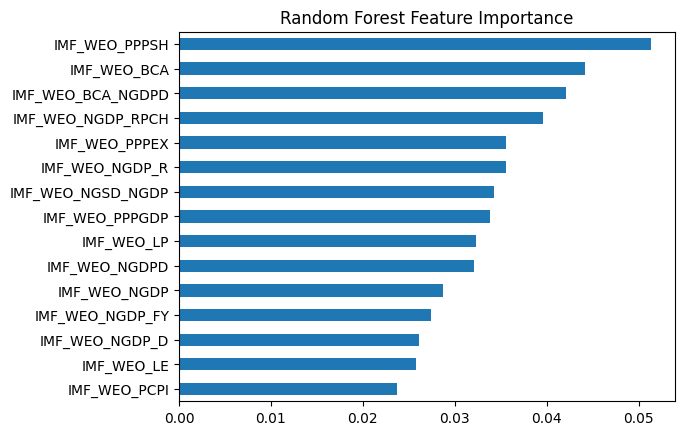


Top XGBoost Features:
IMF_WEO_NGDP_R         0.086504
IMF_WEO_PPPSH          0.043514
IMF_WEO_NGDP_RPCH      0.036874
IMF_WEO_NGDP_D         0.032652
IMF_WEO_PPPGDP         0.032291
IMF_WEO_LP             0.032058
IMF_WEO_BCA            0.031350
IMF_WEO_PPPEX          0.030681
IMF_WEO_NGDP           0.030258
IMF_WEO_BCA_NGDPD      0.029118
IMF_WEO_NGDPPC         0.028784
IMF_WEO_NGSD_NGDP      0.024625
IMF_WEO_NGDP_FY        0.024264
IMF_WEO_GGXCNL_NGDP    0.022677
IMF_WEO_GGXCNL         0.022288
dtype: float32


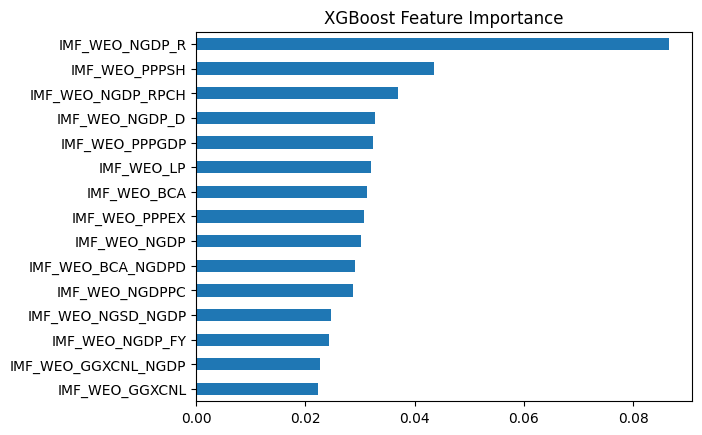

In [54]:
import matplotlib.pyplot as plt

rf = models["RandomForest"]
importances_rf = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)[:15]

print("\nTop RF Features:")
print(importances_rf)

importances_rf.plot(kind="barh")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.show()


xgb = models["XGBoost"]
importances_xgb = pd.Series(xgb.feature_importances_, index=X.columns).sort_values(ascending=False)[:15]

print("\nTop XGBoost Features:")
print(importances_xgb)

importances_xgb.plot(kind="barh")
plt.title("XGBoost Feature Importance")
plt.gca().invert_yaxis()
plt.show()

Logistic Regression feature importance (coefficients)

In [55]:
import numpy as np
import pandas as pd

def logistic_feature_importance(logit_pipeline, feature_names, top_n=20):
    """
    logit_pipeline: Pipeline([('scaler', ...), ('model', LogisticRegression(...))])
    """
    logit = logit_pipeline.named_steps["model"]
    coefs = logit.coef_.ravel()

    fi = pd.DataFrame({
        "feature": feature_names,
        "coef": coefs,
        "abs_coef": np.abs(coefs)
    }).sort_values("abs_coef", ascending=False)

    return fi.head(top_n), fi


logit_top, logit_all = logistic_feature_importance(models["Logistic"], X.columns, top_n=20)
print("Top Logistic features (by |coef|):")
display(logit_top)

Top Logistic features (by |coef|):


,feature,coef,abs_coef
39,IMF_WEO_PPPSH,-1.763780,1.763780
16,IMF_WEO_LE,-1.222548,1.222548
17,IMF_WEO_LP,-1.158404,1.158404
24,IMF_WEO_NGDPRPC,-0.867355,0.867355
7,IMF_WEO_GGXCNL,0.825357,0.825357
1,IMF_WEO_BCA_NGDPD,0.794494,0.794494
22,IMF_WEO_NGDPDPC,0.768923,0.768923
9,IMF_WEO_GGXONLB,-0.691550,0.691550
21,IMF_WEO_NGDPD,0.680897,0.680897
18,IMF_WEO_LUR,-0.579127,0.579127


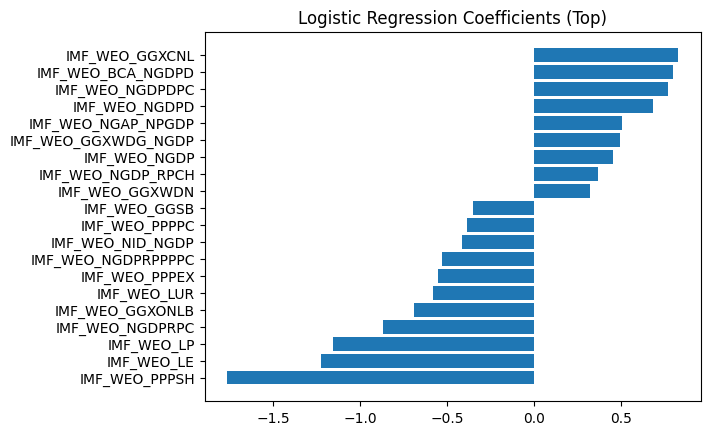

In [56]:
import matplotlib.pyplot as plt

top = logit_top.sort_values("coef")
plt.figure()
plt.barh(top["feature"], top["coef"])
plt.title("Logistic Regression Coefficients (Top)")
plt.show()

In [ ]:
Random Forest feature importance

In [57]:
import pandas as pd

def rf_feature_importance(rf_model, feature_names, top_n=20):
    fi = pd.DataFrame({
        "feature": feature_names,
        "importance": rf_model.feature_importances_
    }).sort_values("importance", ascending=False)

    return fi.head(top_n), fi

rf_top, rf_all = rf_feature_importance(models["RandomForest"], X.columns, top_n=20)
print("Top Random Forest features:")
display(rf_top)

Top Random Forest features:


,feature,importance
39,IMF_WEO_PPPSH,0.051395
0,IMF_WEO_BCA,0.044177
1,IMF_WEO_BCA_NGDPD,0.042107
29,IMF_WEO_NGDP_RPCH,0.039585
36,IMF_WEO_PPPEX,0.035619
28,IMF_WEO_NGDP_R,0.035573
30,IMF_WEO_NGSD_NGDP,0.034324
37,IMF_WEO_PPPGDP,0.033830
17,IMF_WEO_LP,0.032349
21,IMF_WEO_NGDPD,0.032086


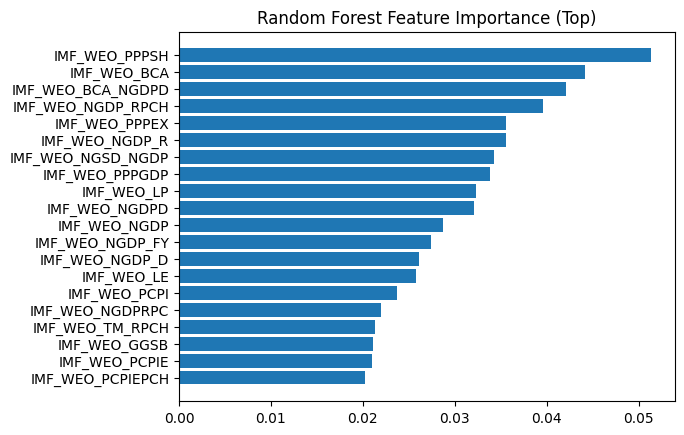

In [58]:
import matplotlib.pyplot as plt

top = rf_top.sort_values("importance")
plt.figure()
plt.barh(top["feature"], top["importance"])
plt.title("Random Forest Feature Importance (Top)")
plt.show()

XGBoost feature importance

In [59]:
import pandas as pd

def xgb_feature_importance(xgb_model, feature_names, top_n=20):
    fi = pd.DataFrame({
        "feature": feature_names,
        "importance": xgb_model.feature_importances_
    }).sort_values("importance", ascending=False)

    return fi.head(top_n), fi

xgb_top, xgb_all = xgb_feature_importance(models["XGBoost"], X.columns, top_n=20)
print("Top XGBoost features:")
display(xgb_top)

Top XGBoost features:


,feature,importance
28,IMF_WEO_NGDP_R,0.086504
39,IMF_WEO_PPPSH,0.043514
29,IMF_WEO_NGDP_RPCH,0.036874
26,IMF_WEO_NGDP_D,0.032652
37,IMF_WEO_PPPGDP,0.032291
17,IMF_WEO_LP,0.032058
0,IMF_WEO_BCA,0.031350
36,IMF_WEO_PPPEX,0.030681
20,IMF_WEO_NGDP,0.030258
1,IMF_WEO_BCA_NGDPD,0.029118


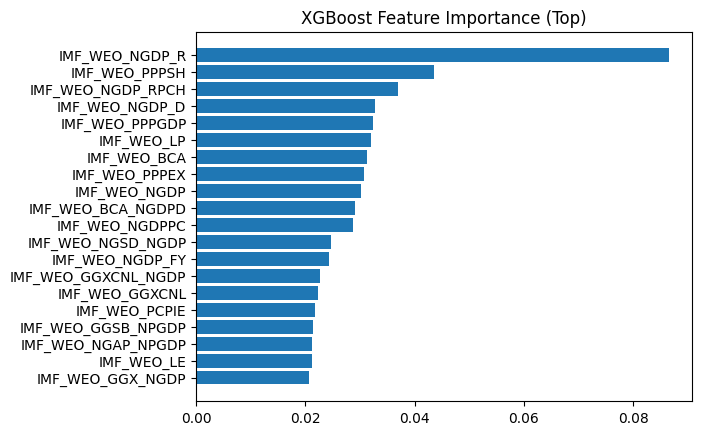

In [60]:
import matplotlib.pyplot as plt

top = xgb_top.sort_values("importance")
plt.figure()
plt.barh(top["feature"], top["importance"])
plt.title("XGBoost Feature Importance (Top)")
plt.show()

Permutation Importance (model-agnostic)

In [62]:
from sklearn.inspection import permutation_importance
import pandas as pd
import numpy as np

def permutation_importance_df(model, X_test, y_test, feature_names, scoring="roc_auc", n_repeats=10):
    r = permutation_importance(model, X_test, y_test, scoring=scoring, n_repeats=n_repeats, random_state=42)
    fi = pd.DataFrame({
        "feature": feature_names,
        "importance_mean": r.importances_mean,
        "importance_std": r.importances_std
    }).sort_values("importance_mean", ascending=False)
    return fi

# For Logistic (pipeline), RF, XGB:
pi_logit = permutation_importance_df(models["Logistic"], X_test, y_test, X.columns, scoring="roc_auc")
pi_rf    = permutation_importance_df(models["RandomForest"], X_test, y_test, X.columns, scoring="roc_auc")
pi_xgb   = permutation_importance_df(models["XGBoost"], X_test, y_test, X.columns, scoring="roc_auc")

print("Permutation importance (Logistic) top 20:")
display(pi_logit.head(20))

print("Permutation importance (RF) top 20:")
display(pi_rf.head(20))

print("Permutation importance (XGB) top 20:")
display(pi_xgb.head(20))

Permutation importance (Logistic) top 20:


,feature,importance_mean,importance_std
39,IMF_WEO_PPPSH,0.070840,0.039409
36,IMF_WEO_PPPEX,0.064177,0.026646
16,IMF_WEO_LE,0.056367,0.036313
17,IMF_WEO_LP,0.054287,0.035399
1,IMF_WEO_BCA_NGDPD,0.052632,0.033416
24,IMF_WEO_NGDPRPC,0.041851,0.022395
7,IMF_WEO_GGXCNL,0.029244,0.016860
29,IMF_WEO_NGDP_RPCH,0.028098,0.017945
25,IMF_WEO_NGDPRPPPPC,0.026698,0.013860
32,IMF_WEO_PCPI,0.023557,0.012033


Permutation importance (RF) top 20:


,feature,importance_mean,importance_std
29,IMF_WEO_NGDP_RPCH,0.015068,0.009102
30,IMF_WEO_NGSD_NGDP,0.013625,0.006929
36,IMF_WEO_PPPEX,0.008531,0.007862
42,IMF_WEO_TXG_RPCH,0.007046,0.003120
19,IMF_WEO_NGAP_NPGDP,0.004839,0.002055
40,IMF_WEO_TMG_RPCH,0.004669,0.003581
28,IMF_WEO_NGDP_R,0.002462,0.004876
8,IMF_WEO_GGXCNL_NGDP,0.002377,0.001218
0,IMF_WEO_BCA,0.002334,0.016546
5,IMF_WEO_GGSB_NPGDP,0.001868,0.001521


Permutation importance (XGB) top 20:


,feature,importance_mean,importance_std
29,IMF_WEO_NGDP_RPCH,0.061545,0.027393
19,IMF_WEO_NGAP_NPGDP,0.014898,0.007311
36,IMF_WEO_PPPEX,0.010866,0.010380
40,IMF_WEO_TMG_RPCH,0.007173,0.006190
43,IMF_WEO_TX_RPCH,0.005688,0.005596
42,IMF_WEO_TXG_RPCH,0.005433,0.008033
3,IMF_WEO_GGR_NGDP,0.005263,0.002874
7,IMF_WEO_GGXCNL,0.003650,0.004833
17,IMF_WEO_LP,0.003183,0.003816
37,IMF_WEO_PPPGDP,0.001868,0.008726


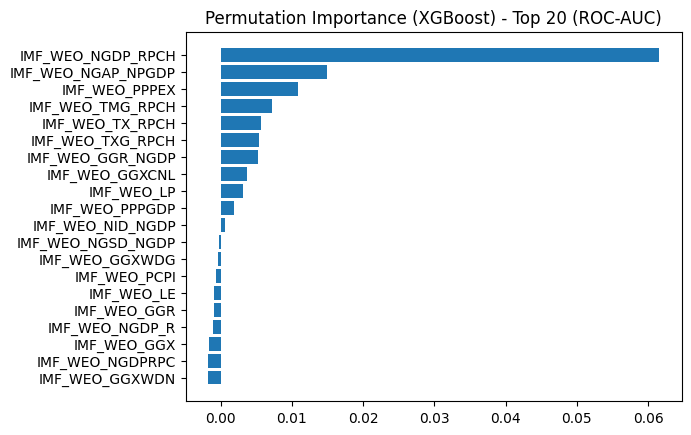

In [63]:
import matplotlib.pyplot as plt

top = pi_xgb.head(20).sort_values("importance_mean")
plt.figure()
plt.barh(top["feature"], top["importance_mean"])
plt.title("Permutation Importance (XGBoost) - Top 20 (ROC-AUC)")
plt.show()